In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [22]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [23]:
cleaned_df = pd.read_csv("/Users/oronje/Desktop/Data_Sprint_2026/data/processed/cleaned_data.csv")

# Univariate Analysis: Understanding One Variable at a Time

In [24]:
numeric_cols = cleaned_df.select_dtypes(include="number").columns
cleaned_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
household_size,20871.0,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
monthly_income,20871.0,9702.774280,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
prodsum1,20871.0,3.936563,3.227992,0.0,1.0,3.0,6.0,22.0


 🔍Monthly Income Interpretation
- The mean is almost double the median, indicating a strong right-skewed distribution.
- Most individuals earn around 5,000–10,000, but a small group earns extremely high incomes.
- The maximum value (200,000) is a major outlier compared to the typical population.

⚠️ Insight
Income distribution is highly unequal, with a few high-income individuals pulling the average upward.
This is typical of financial datasets in developing economies.
Median is a more reliable measure than mean here.

🔍 Household Size interpretation
- The average household has ~4 people, which is typical for many Kenyan households.
- The median (4) is close to the mean → distribution is fairly balanced.
- However, the maximum value (20) is very high and suggests outliers or extended family households.

⚠️ Insight
Some households are significantly larger than the norm, which may indicate:
extended families,
data entry errors,
or shared housing arrangements

🔍 Financial Product Usage (prodsum1)Interpretation
- On average, individuals use about 4 financial products/services.
- The median (3) suggests most people use fewer products than the average.
- The maximum (22) indicates a small group with very high financial engagement.

⚠️ Insight
Distribution is moderately skewed to the right.
There is a clear divide between:
low financial inclusion users (0–3 products)
highly engaged users (10+ products)

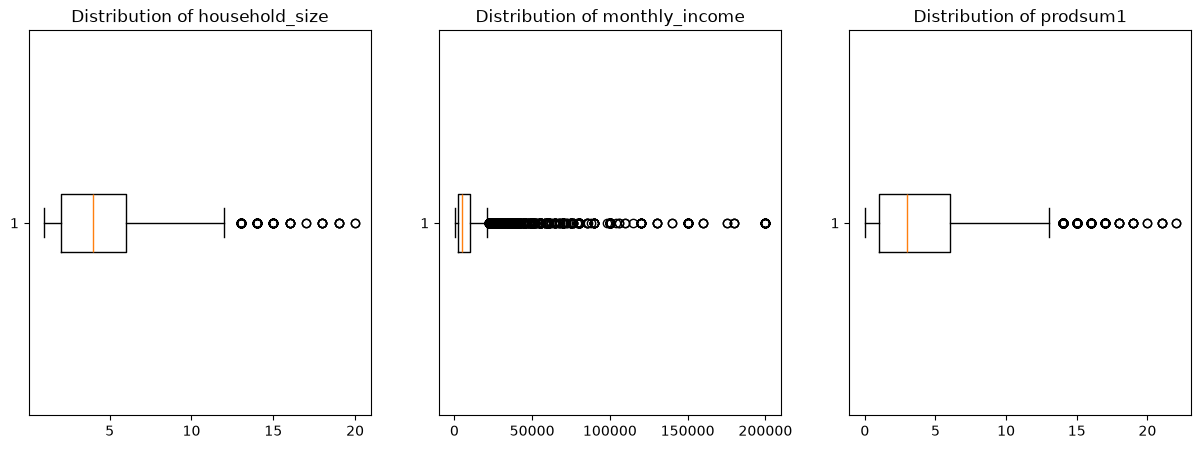

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax,col in zip(axes, numeric_cols):
    ax.boxplot(cleaned_df[col],vert=False)
    ax.set_title(f"Distribution of {col}")

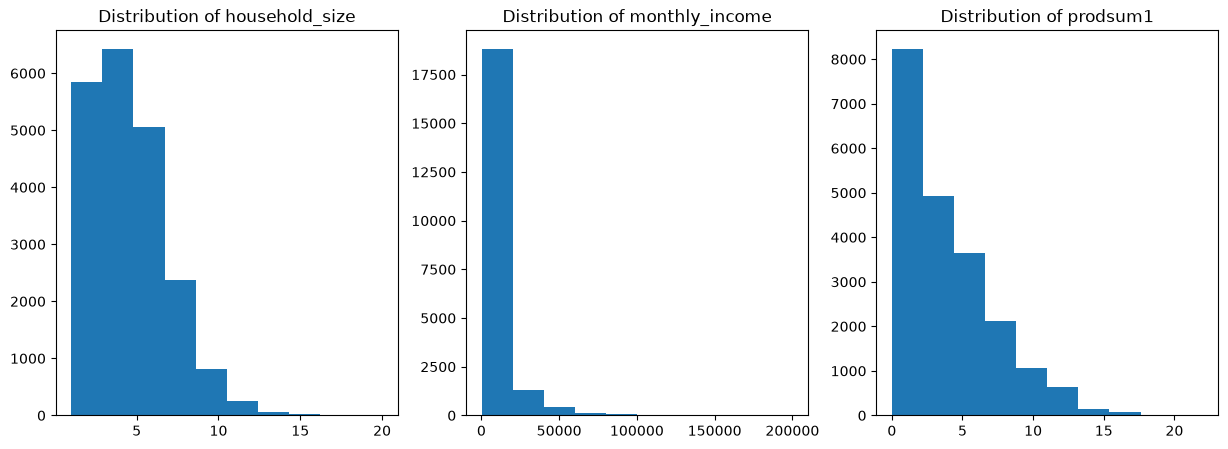

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax,col in zip(axes, numeric_cols):
    ax.hist(cleaned_df[col])
    ax.set_title(f"Distribution of {col}")

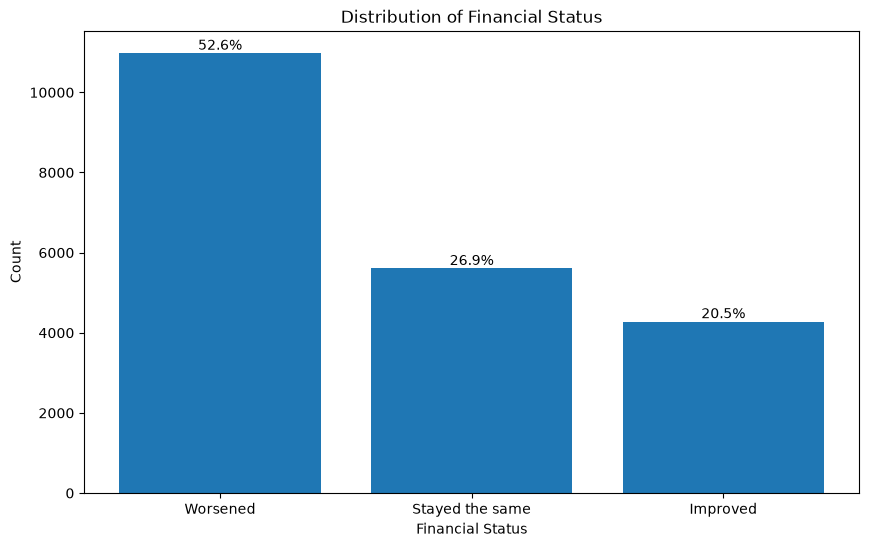

In [27]:
counts = cleaned_df["financial_status"].value_counts()
percentages = cleaned_df["financial_status"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(counts.index, counts.values)

ax.set_xlabel("Financial Status")
ax.set_ylabel("Count")
ax.set_title("Distribution of Financial Status")

for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

Financial Status Distribution

- The financial status of respondents shows a clear skew toward negative outcomes. A majority of individuals (52.6%) report that their financial situation has worsened, while 26.9% report no change. Only 20.5% experienced an improvement in their financial status.

- This suggests that financial decline is the most common outcome in the dataset, indicating potential exposure to economic shocks and limited upward financial mobility among respondents.

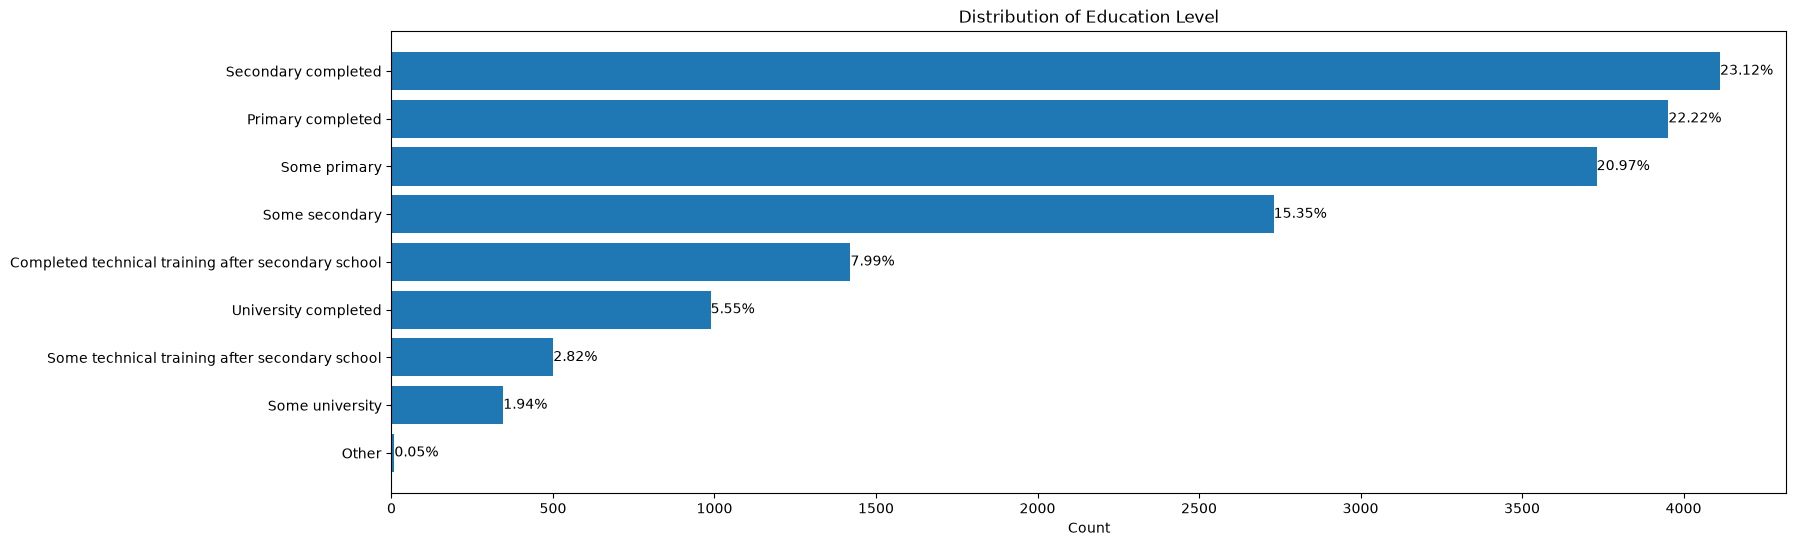

In [28]:
counts = cleaned_df["education_level"].value_counts().sort_values(ascending=True)
percentages = cleaned_df["education_level"].value_counts(normalize=True).loc[counts.index] * 100

fig, ax = plt.subplots(figsize=(18,6))

bars = ax.barh(counts.index, counts.values)

ax.set_xlabel("Count")
ax.set_title("Distribution of Education Level")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{pct:.2f}%",
        va="center"
    )

plt.show()

📊 Education Level Distribution (Summary)

Most respondents have primary or secondary education, with Secondary completed (19.7%), Primary completed (18.9%), and Some primary (17.9%) forming the largest groups. A notable 14.7% have no formal education.

Higher education levels are less common, with university completed (4.7%) and technical training (6.8%) representing a small share of the population. The “Other” category is negligible (0.04%).

🔍 Key Insight

The population is largely concentrated in lower to mid-level education, with limited tertiary education attainment.

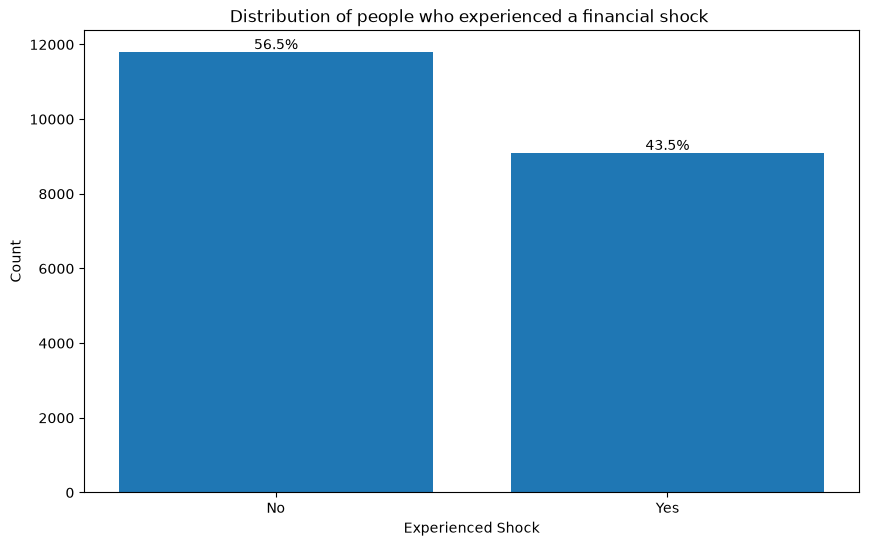

In [29]:
counts = cleaned_df["experienced_shock"].value_counts()
percentages = cleaned_df["experienced_shock"].value_counts(normalize=True) * 100

fig,ax = plt.subplots(figsize=(10,6))
bars = ax.bar(counts.index, counts.values)
ax.set_xlabel("Experienced Shock")
ax.set_ylabel("Count")
ax.set_title("Distribution of people who experienced a financial shock ")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

⚡ Experienced Financial Shock (Summary)

The dataset shows that 43.5% of respondents have experienced a financial shock, while 56.5% have not.

🔍 Key Insight

A significant portion of the population has been exposed to financial shocks, indicating a relatively high level of economic vulnerability. This variable is likely an important driver of financial outcomes in subsequent analysis.

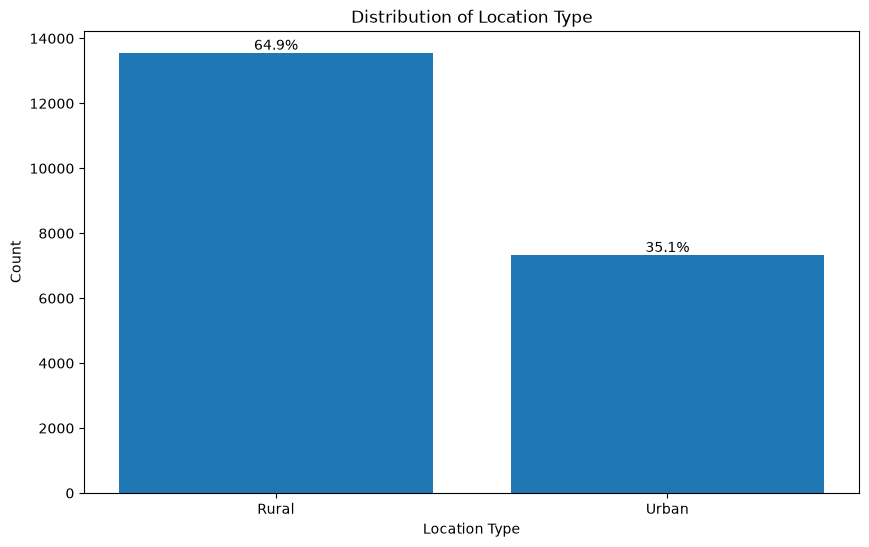

In [30]:
counts = cleaned_df["location_type"].value_counts()
percentages = cleaned_df["location_type"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(counts.index, counts.values)
ax.set_xlabel("Location Type")
ax.set_ylabel("Count")
ax.set_title("Distribution of Location Type")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

Location Type (Summary)

The majority of respondents are based in rural areas (64.9%), while 35.1% are urban residents.

🔍 Key Insight

The dataset is predominantly rural, suggesting that any financial trends or outcomes observed are largely driven by rural populations. This may have important implications for access to services, financial inclusion, and vulnerability to economic shocks.

# Bivariate Analysis 

Financial Status by Experienced Shock

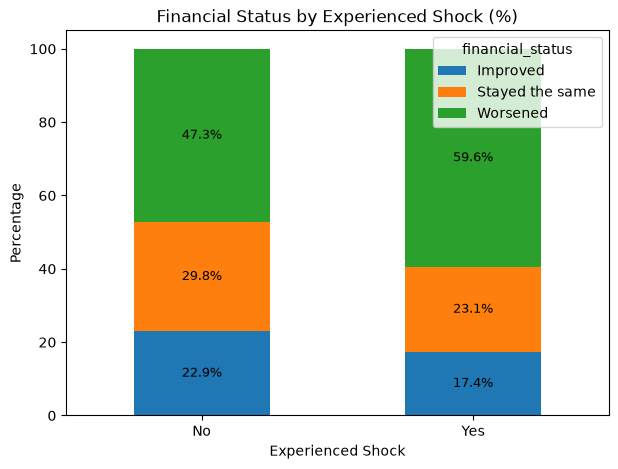

In [31]:
shock_table = (
    cleaned_df
    .groupby("experienced_shock")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)

fig, ax = plt.subplots(figsize=(7,5))

shock_table.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Financial Status by Experienced Shock (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Experienced Shock")
plt.xticks(rotation=0)

for i, shock in enumerate(shock_table.index):
    bottom = 0  

    for status in shock_table.columns:
        value = shock_table.loc[shock, status]

        if value > 0:  
            ax.text(
                i,                      
                bottom + value / 2,     
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += value  

plt.show()

⚡ Financial Status by Experienced Shock (Summary)
- The data shows a clear relationship between experiencing a financial shock and poorer financial outcomes.
- Among respondents who did not experience a shock, a smaller share report worsening financial status (47.3%), compared to those who experienced a shock, where the proportion of respondents with worsened financial status rises to 59.6%.
- Conversely, respondents with no shocks are more likely to report stable or improved outcomes compared to those who experienced shocks.

🔍 Key Insight
Experiencing a financial shock is strongly associated with worse financial outcomes, suggesting that shocks are a major driver of financial vulnerability in the dataset.

Financial Status by Education Level 

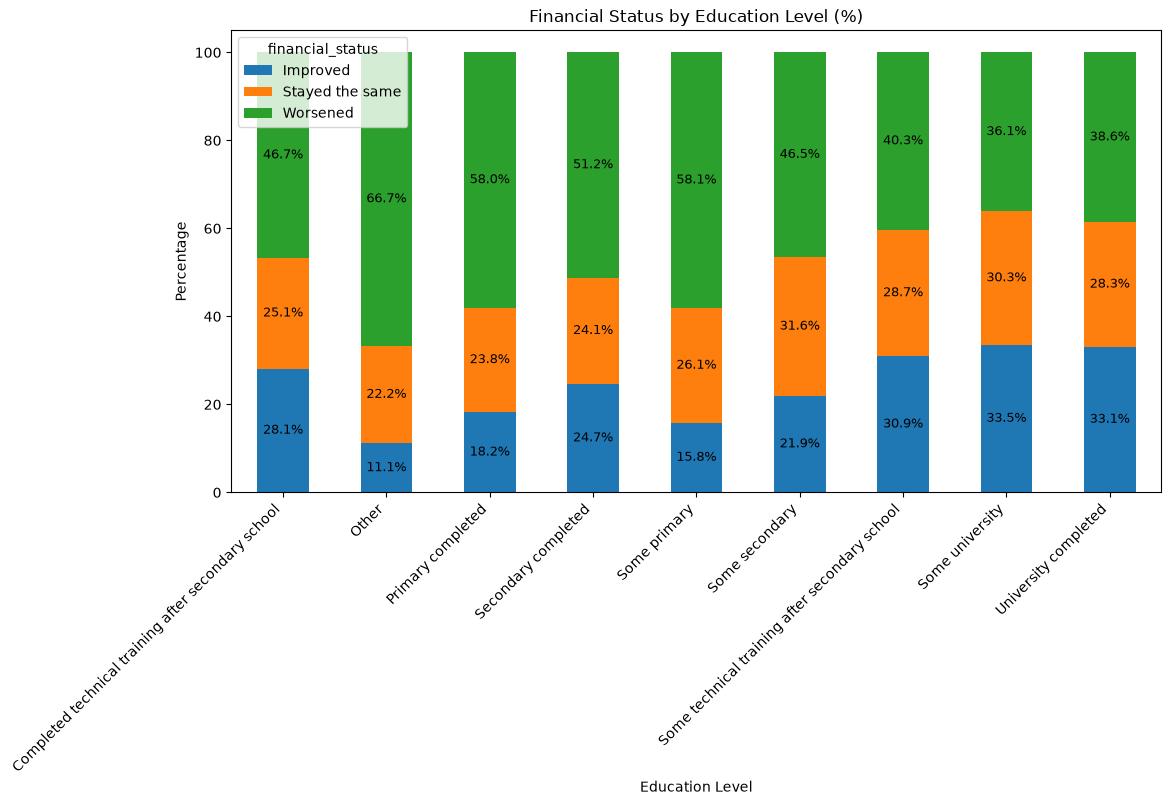

In [32]:
edu_table = (
    cleaned_df
    .groupby("education_level")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)
fig, ax = plt.subplots(figsize=(12,6))
edu_table.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Financial Status by Education Level (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Education Level")
plt.xticks(rotation=45, ha="right")

for i, edu in enumerate(edu_table.index):
    bottom = 0  

    for status in edu_table.columns:
        value = edu_table.loc[edu, status]

        if value > 0:  
            ax.text(
                i,                      
                bottom + value / 2,     
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += value

🎓 Financial Status by Education Level (Summary)

- There is a clear relationship between education level and financial outcomes in the dataset.

- Respondents with higher education levels, such as university completed (33.1% improved, 38.6% worsened) and some university (33.5% improved, 36.1% worsened), tend to report better financial outcomes and lower rates of financial decline compared to those with lower education levels.

- In contrast, individuals with no formal education (57.3% worsened) and primary completed (58.0% worsened) show significantly higher proportions of financial deterioration.

🔍 Key Insight

Higher education is associated with better financial resilience, while lower education levels are linked to a greater likelihood of financial decline.

Financial Status by Location type 

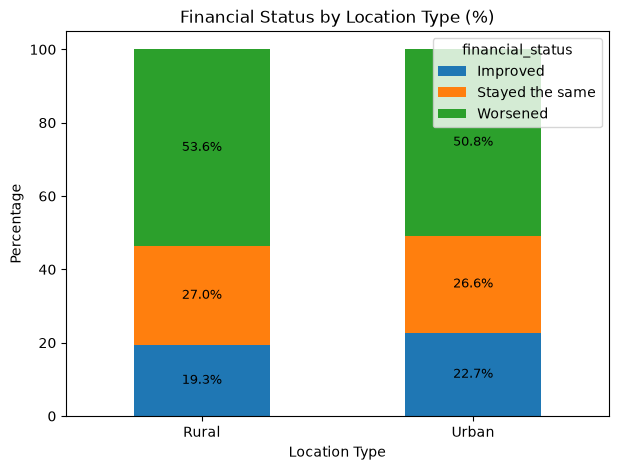

In [33]:
loc_table = (
    cleaned_df
    .groupby("location_type")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)
fig, ax = plt.subplots(figsize=(7,5))
loc_table.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Financial Status by Location Type (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Location Type")
plt.xticks(rotation=0)
for i, loc in enumerate(loc_table.index):
    bottom = 0  
    for status in loc_table.columns:
        value = loc_table.loc[loc, status]
        if value > 0:  
            ax.text(
                i,                      
                bottom + value / 2,     
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )
            bottom += value

🌍 Financial Status by Location Type (Summary)
- The distribution shows differences in financial outcomes between rural and urban respondents.
- Rural residents report a higher proportion of worsened financial status (53.6%) compared to urban residents (50.8%). Urban respondents, however, have slightly higher rates of improvement (22.7% vs 19.3%).

🔍 Key Insight
Urban respondents appear to have slightly better financial resilience, with lower levels of financial decline and marginally higher improvement rates compared to rural respondents.

Financial Status by Monthly income 

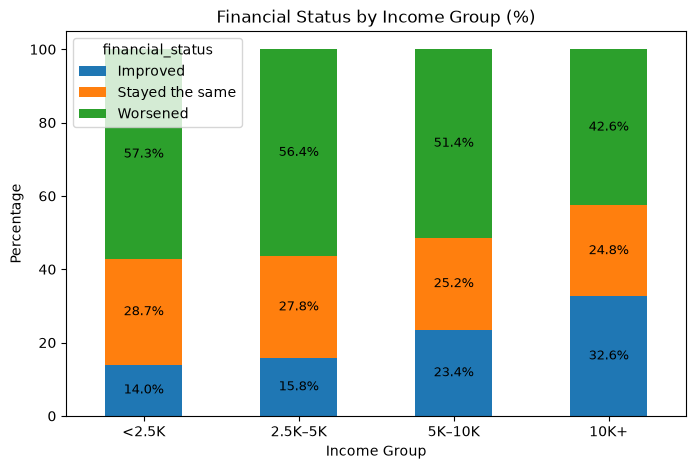

In [34]:
cleaned_df["income_group"] = pd.cut(
    cleaned_df["monthly_income"],
    bins=[0, 2500, 5000, 10000, float("inf")],
    labels=["<2.5K", "2.5K–5K", "5K–10K", "10K+"]
)
income_table = (
    cleaned_df
    .groupby("income_group")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)
fig, ax = plt.subplots(figsize=(8,5))

income_table.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Financial Status by Income Group (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Income Group")
plt.xticks(rotation=0)


for i, loc in enumerate(income_table.index):
    bottom = 0

    for status in income_table.columns:
        value = income_table.loc[loc, status]

        if value > 0:
            ax.text(
                i,
                bottom + value / 2,
                f"{value:.1f}%",  
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += value

plt.show()

💰 Financial Status by Income Group (Summary)

- There is a clear income gradient in financial outcomes. Respondents in the lowest income group (<2.5K) report the highest financial decline (57.3% worsened) and the lowest improvement (14.0%).
- As income increases, financial outcomes improve steadily. In the highest income group (10K+), the proportion reporting worsened financial status drops to 42.6%, while improvement rises to 32.6%.

🔍 Key Insight
Higher income is strongly associated with better financial resilience, with a clear transition from high vulnerability at low income levels to greater stability and improvement at higher income levels.

#  Binary Encoding

In [35]:
# Binary categorical columns (2 unique values)
binary_cols = [col for col in cleaned_df.columns if cleaned_df[col].nunique() == 2]
# Map binary categorical columns to 0 and 1
cleaned_df[binary_cols] = cleaned_df[binary_cols].replace({
    'Urban': 1, 'Rural': 0,
    'Male': 1, 'Female': 0,
    'Usage': 1, 'Non-usage': 0,
    'Yes': 1, 'No': 0,
    'With Disability': 1, 'Without Disability': 0
})

cleaned_df[binary_cols] = cleaned_df[binary_cols].astype("int64")

#  Multicollinearity Analysis

In [36]:
#  Drop target 
X_vif = cleaned_df.drop(columns=["financial_status"], errors="ignore")

# Force ALL categorical columns to numeric via one-hot encoding
X_vif = pd.get_dummies(X_vif, drop_first=True)

print(X_vif.dtypes.value_counts())  # must be ONLY int/float

# Convert to float matrix
X_matrix = X_vif.astype(float).values

# 8. Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_matrix, i)
    for i in range(X_matrix.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False)

bool     87
int64    20
Name: count, dtype: int64


,feature,VIF
10,mobile_money_access,66.197299
9,formal_service_use,64.509974
18,prodsum1,13.222930
11,mobile_ownership_1,13.111201
95,barriers_bank_Affordability,10.654375
67,Age_26-35,9.505764
79,marital_status_Married/Living with partner,8.939372
70,Age_Above 55,7.984571
99,barriers_bank_No barrier,7.608842
68,Age_36-45,7.466000


📊 VIF / Multicollinearity Summary

- VIF analysis shows that most features have low to moderate multicollinearity (VIF < 5), indicating generally stable relationships across predictors. 
- However, a few variables—especially mobile_money_access (~66) and formal_service_use (~65)—exhibit high multicollinearity, suggesting overlapping information.

- No features were dropped, as the chosen models (Random Forest, XGBoost, LightGBM) are tree-based and robust to multicollinearity. 
- Therefore, all variables were retained to preserve predictive signal.